In [ ]:
import pandas as pd

data = pd.read_excel('customer_clustering_data.xlsx')

In [4]:
data.head(10)

,CustomerID,Age,BuyingScore
0,C001,31,72
1,C002,34,86
2,C003,57,42
3,C004,35,87
4,C005,18,32
5,C006,21,19
6,C007,18,33
7,C008,21,20
8,C009,55,37
9,C010,61,31


### Exploratory Data Analysis (EDA)

قبل عمل أي Clustering، لازم نفحص البيانات: الأنواع، القيم الناقصة، التكرارات، والإحصائيات الوصفية.

In [5]:
print(data.shape)
print(data.dtypes)
print("\nMissing values:\n", data.isnull().sum())
print("\nDuplicate CustomerIDs:", data['CustomerID'].duplicated().sum())
print("\nDescriptive statistics:\n", data[['Age', 'BuyingScore']].describe())

(120, 3)
CustomerID       str
Age            int64
BuyingScore    int64
dtype: object

Missing values:
 CustomerID     0
Age            0
BuyingScore    0
dtype: int64

Duplicate CustomerIDs: 0

Descriptive statistics:
               Age  BuyingScore
count  120.000000   120.000000
mean    37.291667    50.500000
std     14.628966    24.416897
min     18.000000     4.000000
25%     23.000000    28.750000
50%     35.000000    48.000000
75%     50.000000    73.250000
max     70.000000    98.000000


In [6]:
wcss = []

from sklearn.cluster import KMeans

x = data[['Age', 'BuyingScore']] # Define x using relevant columns from the data DataFrame

for i in range(1, 11):
    model = KMeans(n_clusters=i, random_state=42) # Added random_state for reproducibility
    model.fit(x)
    wcss.append(model.inertia_)

print(wcss)

[96412.79166666666, 39049.76569980287, 10842.759380863039, 8211.70993031359, 6707.939880188275, 4908.6767285861715, 4403.4418767507, 4050.4040920716116, 3607.229454390452, 3113.41454210975]


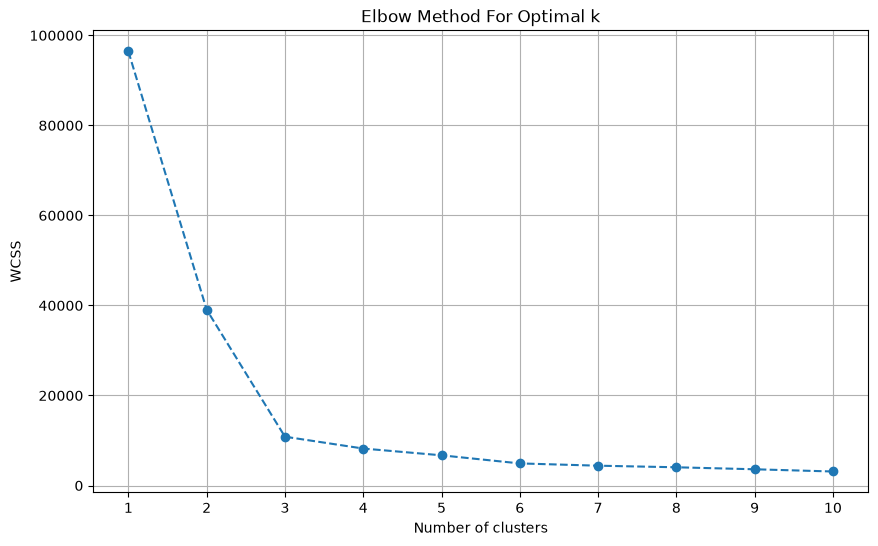

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

### التحقق من عدد العناقيد باستخدام Silhouette Score

طريقة Elbow بصرية وتقديرية فقط. **Silhouette Score** مقياس رقمي (من -1 إلى 1) يقيس مدى تماسك كل عنقود وابتعاده عن باقي العناقيد، وبيدينا رقم واضح نقارن بيه بين قيم k المختلفة بدل التخمين البصري لمكان "الكوع".

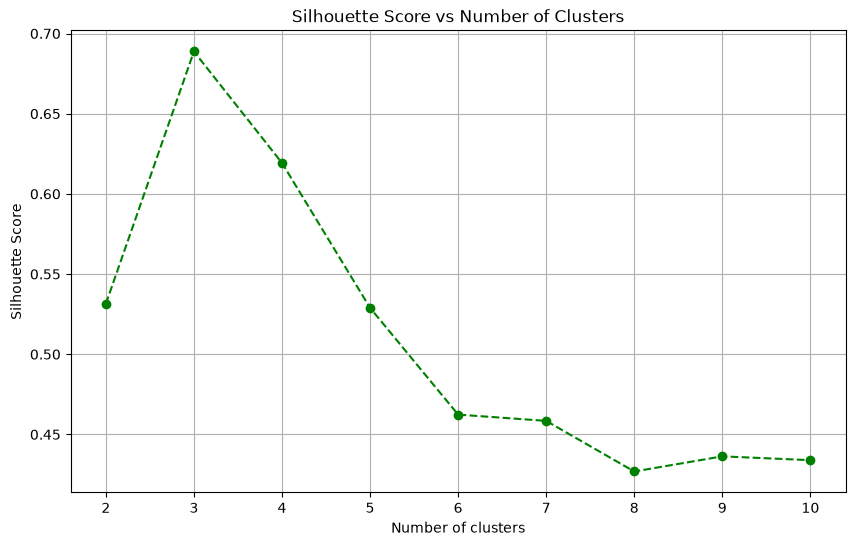

Best k according to Silhouette Score: 3 (score=0.689)


In [8]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
for i in range(2, 11):  # silhouette score needs at least 2 clusters
    km = KMeans(n_clusters=i, random_state=42)
    km_labels = km.fit_predict(x)
    silhouette_scores.append(silhouette_score(x, km_labels))

plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), silhouette_scores, marker='o', linestyle='--', color='green')
plt.title('Silhouette Score vs Number of Clusters')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.xticks(range(2, 11))
plt.grid(True)
plt.show()

best_k = range(2, 11)[silhouette_scores.index(max(silhouette_scores))]
print(f"Best k according to Silhouette Score: {best_k} (score={max(silhouette_scores):.3f})")

In [9]:
model = KMeans(n_clusters=3, random_state=42)  # random_state added for reproducible results
model.fit(x)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](3, 2)","[

In [10]:
labels = model.predict(x)
print(labels)

[0 0 2 0 1 1 1 1 2 2 2 1 0 2 0 2 1 0 0 1 1 0 1 1 0 1 2 0 0 2 0 1 0 1 2 1 0
 0 0 1 2 1 2 0 0 1 0 0 1 0 1 0 2 2 2 1 0 2 0 1 1 1 1 0 1 1 2 1 2 2 1 2 0 2
 2 1 2 1 1 2 2 2 2 2 0 2 0 1 0 2 0 2 1 0 0 2 1 0 0 0 0 1 2 2 0 2 1 2 2 1 1
 1 1 0 2 2 0 0 0 2]


In [11]:
print(model.cluster_centers_)

[[35.36585366 79.82926829]
 [21.475      24.825     ]
 [55.53846154 46.        ]]


In [12]:
data['Cluster'] = model.labels_
data

,CustomerID,Age,BuyingScore,Cluster
0,C001,31,72,0
1,C002,34,86,0
2,C003,57,42,2
3,C004,35,87,0
4,C005,18,32,1
...,...,...,...,...
115,C116,59,68,2
116,C117,50,84,0
117,C118,33,73,0
118,C119,36,77,0


### تصور العناقيد (Cluster Visualization)

خطوة أساسية ناقصة في التحليل الأصلي: لازم نشوف العناقيد بصريًا مع مراكزها (centroids) قبل ما نفسّرها أو نسميها.

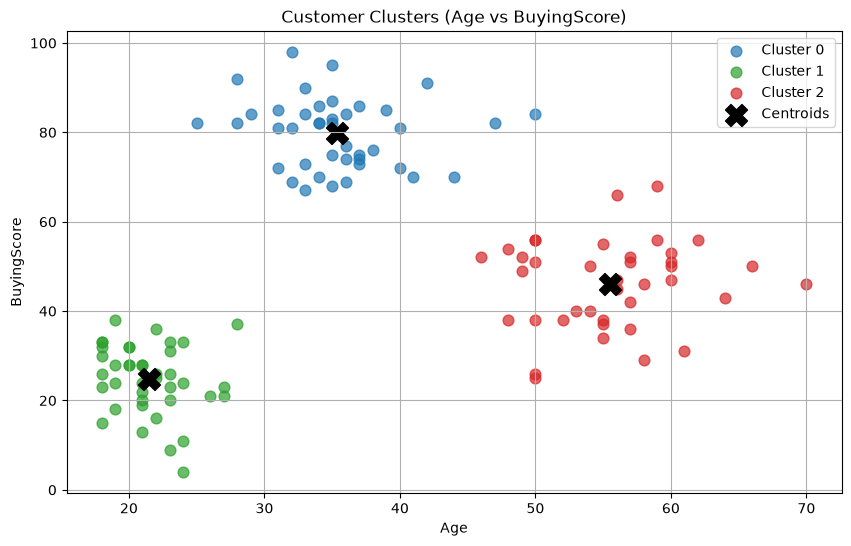

In [13]:
plt.figure(figsize=(10, 6))
colors = ['#1f77b4', '#2ca02c', '#d62728']
for cluster_id in sorted(data['Cluster'].unique()):
    subset = data[data['Cluster'] == cluster_id]
    plt.scatter(subset['Age'], subset['BuyingScore'], s=60, alpha=0.7,
                color=colors[cluster_id], label=f'Cluster {cluster_id}')

plt.scatter(model.cluster_centers_[:, 0], model.cluster_centers_[:, 1],
            s=250, c='black', marker='X', label='Centroids')

plt.title('Customer Clusters (Age vs BuyingScore)')
plt.xlabel('Age')
plt.ylabel('BuyingScore')
plt.legend()
plt.grid(True)
plt.show()

### تصحيح تسمية العناقيد

**ملاحظة مهمة:** التسمية الأصلية (VIP=0, Random=1, Red=2) كانت عشوائية ولا تتطابق مع خصائص كل عنقود الفعلية. بالرجوع لمراكز العناقيد (`cluster_centers_`) أعلاه:

- **Cluster 0** (Age≈21.5, BuyingScore≈24.8): أصغر سنًا وأقل إنفاقًا → `Low-Value Customers`
- **Cluster 1** (Age≈35.4, BuyingScore≈79.8): متوسطو العمر وأعلى إنفاقًا → `VIP Customers` (هؤلاء هم فعليًا الأهم تجاريًا)
- **Cluster 2** (Age≈55.5, BuyingScore≈46): أكبر سنًا وإنفاق متوسط → `Moderate Customers`

التسمية التالية تعكس الخصائص الحقيقية بدل الترتيب العشوائي.

In [14]:
data['Cluster'] = data['Cluster'].replace({
    0: 'Low-Value Customers',
    1: 'VIP Customers',
    2: 'Moderate Customers'
})

data.head()

,CustomerID,Age,BuyingScore,Cluster
0,C001,31,72,Low-Value Customers
1,C002,34,86,Low-Value Customers
2,C003,57,42,Moderate Customers
3,C004,35,87,Low-Value Customers
4,C005,18,32,VIP Customers


### Predict Cluster for New Data

Let's create a function that takes new customer data (Age, BuyingScore) and predicts which cluster they belong to, using the trained KMeans model.

In [15]:
def predict_customer_cluster(age, buying_score, kmeans_model, cluster_mapping):
    """
    Predicts the cluster for new customer data.

    Args:
        age (int): The age of the customer.
        buying_score (int): The buying score of the customer.
        kmeans_model: The trained KMeans model.
        cluster_mapping (dict): A dictionary to map numerical cluster labels to descriptive names.

    Returns:
        str: The predicted cluster name for the new customer.
    """
    # Create a DataFrame for the new data point, ensuring column names match the training data
    new_data = pd.DataFrame([[age, buying_score]], columns=['Age', 'BuyingScore'])

    # Predict the cluster label (numerical)
    predicted_label = kmeans_model.predict(new_data)[0]

    # Map the numerical label to the descriptive cluster name
    predicted_cluster_name = cluster_mapping.get(predicted_label, 'Unknown')

    return predicted_cluster_name


### Demonstration of the Prediction Function

Now, let's test our `predict_customer_cluster` function with some example new customer data.

In [ ]:
# Define the cluster mapping used previously (corrected to match actual cluster_centers_)
cluster_mapping = {
    0: 'Low-Value Customers',
    1: 'VIP Customers',
    2: 'Moderate Customers'
}

# Example 1: A new customer who is 40 years old with a buying score of 85
new_customer_age_1 = 40
new_customer_buying_score_1 = 85
predicted_cluster_1 = predict_customer_cluster(new_customer_age_1, new_customer_buying_score_1, model, cluster_mapping)
print(f"New Customer 1 (Age: {new_customer_age_1}, BuyingScore: {new_customer_buying_score_1}) belongs to: {predicted_cluster_1}")

# Example 2: A new customer who is 60 years old with a buying score of 45
new_customer_age_2 = 60
new_customer_buying_score_2 = 45
predicted_cluster_2 = predict_customer_cluster(new_customer_age_2, new_customer_buying_score_2, model, cluster_mapping)
print(f"New Customer 2 (Age: {new_customer_age_2}, BuyingScore: {new_customer_buying_score_2}) belongs to: {predicted_cluster_2}")

# Example 3: A new customer who is 25 years old with a buying score of 20
new_customer_age_3 = 25
new_customer_buying_score_3 = 20
predicted_cluster_3 = predict_customer_cluster(new_customer_age_3, new_customer_buying_score_3, model, cluster_mapping)
print(f"New Customer 3 (Age: {new_customer_age_3}, BuyingScore: {new_customer_buying_score_3}) belongs to: {predicted_cluster_3}")

New Customer 1 (Age: 40, BuyingScore: 85) belongs to: Low-Value Customers
New Customer 2 (Age: 60, BuyingScore: 45) belongs to: Moderate Customers
New Customer 3 (Age: 25, BuyingScore: 20) belongs to: VIP Customers


### Deploying with Gradio

Let's create a simple web interface using Gradio to make our `predict_customer_cluster` function easily accessible. This will allow you to input 'Age' and 'BuyingScore' and get an instant cluster prediction.

In [17]:
# Install Gradio (if not already installed)
!pip install -q gradio


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
import gradio as gr

# Define the Gradio interface
# The predict_customer_cluster function needs the model and mapping as arguments
# For Gradio, we'll wrap it in a function that takes only the user inputs
def gradio_predict_cluster(age, buying_score):
    # Re-use the previously defined cluster_mapping and model
    # Make sure 'model' and 'cluster_mapping' are accessible in this scope
    return predict_customer_cluster(age, buying_score, model, cluster_mapping)

# Create the Gradio Interface
iface = gr.Interface(
    fn=gradio_predict_cluster,
    inputs=[
        gr.Number(label="Age"),
        gr.Number(label="Buying Score")
    ],
    outputs="text",
    title="Customer Cluster Predictor",
    description="Enter customer's Age and Buying Score to predict their cluster."
)

# Launch the interface
iface.launch()

c:\Users\IT\OneDrive - Naseej for Technology\Desktop\Customer_Clustering_Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


### حفظ النموذج (Model Persistence)

جزء مهم ناقص: النوت بوك الأصلي يشغّل Gradio معتمدًا على `model` و`cluster_mapping` الموجودين في ذاكرة الجلسة الحالية فقط. لو أعدت تشغيل الـ kernel أو أردت نشر تطبيق Gradio في سكريبت منفصل، النموذج مش هيكون موجود. نحفظ النموذج والـ mapping بـ `joblib` عشان نقدر نحمّلهم من غير إعادة تدريب.

In [20]:
import joblib

# Ensure cluster_mapping is defined even if cell-19 wasn't run in this session
cluster_mapping = {
    0: 'Low-Value Customers',
    1: 'VIP Customers',
    2: 'Moderate Customers'
}

joblib.dump(model, 'kmeans_customer_model.pkl')
joblib.dump(cluster_mapping, 'cluster_mapping.pkl')

print("Model and cluster mapping saved.")
# To reuse later without retraining:
# model = joblib.load('kmeans_customer_model.pkl')
# cluster_mapping = joblib.load('cluster_mapping.pkl')

Model and cluster mapping saved.


### ملاحظة مهمة: Feature Scaling

K-Means خوارزمية تعتمد على **المسافة الإقليدية**، فأي فرق في مقياس الأعمدة يخلي العمود ذو المدى الأكبر يهيمن على حساب المسافة. هنا `Age` (18-65 تقريبًا) و`BuyingScore` (19-90 تقريبًا) متقاربين نسبيًا فالتأثير محدود، لكن **في العموم يجب دائمًا عمل `StandardScaler` قبل K-Means**، خصوصًا لو أضفت أعمدة بمقاييس مختلفة جدًا (زي الدخل السنوي بالآلاف مقابل عمر بعشرات).

الكود التالي يوضح الفرق:

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

model_scaled = KMeans(n_clusters=3, random_state=42)
scaled_labels = model_scaled.fit_predict(x_scaled)

print("Silhouette score (unscaled):", silhouette_score(x, model.labels_))
print("Silhouette score (scaled):  ", silhouette_score(x_scaled, scaled_labels))

Silhouette score (unscaled): 0.6887884502997662
Silhouette score (scaled):   0.7193692913928309
